# Sistema de inferencia difuso Mamdani con scikit-fuzzy

## Ejemplo ejecutable: propina en un restaurante

[scikit-fuzzy](https://pythonhosted.org/scikit-fuzzy/) permite definir variables lingüísticas, funciones de pertenencia y reglas para construir sistemas de inferencia difusa en Python.

En un entorno nuevo, instale las dependencias con `%pip install numpy matplotlib scikit-fuzzy`.

## Objetivo

Construir un sistema Mamdani que reciba dos calificaciones numéricas y recomiende una propina. El ejemplo recorre el mismo flujo de la presentación: fusificación, evaluación de reglas, implicación, agregación y desfusificación por centroide.

## Caso: propina

Una persona califica la calidad de la comida y la atención entre $1.0$ y $7.0$. A partir de esas dos entradas, el sistema recomienda una propina entre $0$ y $15\%$.

No se fija un corte exacto para cada apreciación. En su lugar, las calificaciones se representan mediante términos graduales:

- Calidad: `pésima`, `malita`, `piola`, `de pana`, `basadísima`.
- Atención: `amarga`, `pesada`, `noesni`, `tela`, `joya`.
- Propina: `nada`, `poca`, `normal`, `extra`.

La fusificación ocurre cuando una calificación numérica activa estos términos. La desfusificación ocurre al final, cuando el sistema convierte la propina difusa agregada en un porcentaje único.

<center><img src="../images/fuzzylogic_system.png" align="center"/></center>

Las entradas numéricas son `calidad` y `atención`. Las reglas producen conjuntos difusos sobre `propina`; el centroide entrega finalmente el porcentaje recomendado.

<center><img src="../images/fuzzy_steps.png" align="center"/></center>

En el código, `compute()` ejecuta este flujo completo sobre las entradas asignadas a la simulación.

## Variables lingüísticas

### Entradas

| Variable en el código | Universo numérico | Términos lingüísticos |
|---|---|---|
| `calidad` | $[1.0, 7.0]$ | pésima, malita, piola, de pana, basadísima |
| `atención` | $[1.0, 7.0]$ | amarga, pesada, noesni, tela, joya |

Ambos universos se discretizan en pasos de $0.1$, para que la biblioteca pueda representar y operar los conjuntos difusos.

### Salida

La variable `propina` tiene universo $[0,15]\%$ y los términos `nada`, `poca`, `normal` y `extra`. Es un consecuente: las reglas activan conjuntos sobre este universo antes de calcular un único porcentaje.

In [1]:
# Dependencias
import numpy as np
import skfuzzy as fuzz

from skfuzzy import control as ctrl

In [2]:
# Antecedentes: entradas numéricas que se fusificarán.
calidad = ctrl.Antecedent(np.arange(1, 7.1, 0.1), 'calidad')
atención = ctrl.Antecedent(np.arange(1, 7.1, 0.1), 'atención')

# Consecuente: conjunto difuso de salida antes de desfusificar.
propina = ctrl.Consequent(np.arange(0, 15.1, 0.1), 'propina')
propina.defuzzify_method = 'centroid'
propina.accumulation_method = np.fmax

# .universe contiene los valores discretos del dominio numérico.

## Funciones de pertenencia

/home/polivares/.local/share/mamba/envs/IPD434/lib/python3.10/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/home/polivares/.local/share/mamba/envs/IPD434/lib/python3.10/site-packages/skfuzzy/control/term.py:72: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


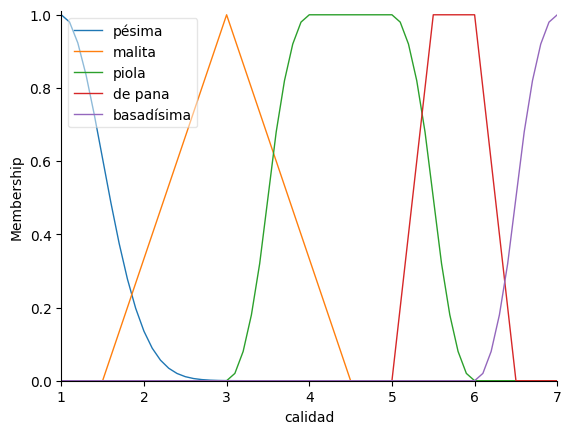

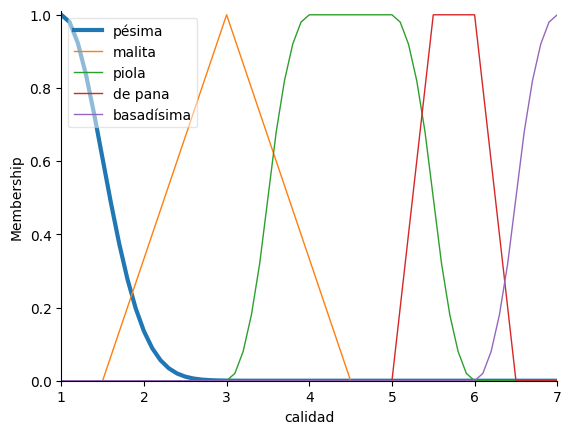

In [3]:
# Cada término lingüístico se asocia a una función de pertenencia.
# Las formas se superponen: una misma calificación puede activar varios términos.
calidad['pésima'] = fuzz.gaussmf(calidad.universe, 1, 0.5)
calidad['malita'] = fuzz.trimf(calidad.universe, [1.5, 3, 4.5])
calidad['piola'] = fuzz.pimf(calidad.universe, 3, 4, 5, 6)
calidad['de pana'] = fuzz.trapmf(calidad.universe, [5, 5.5, 6.0, 6.5])
calidad['basadísima'] = fuzz.smf(calidad.universe, 6.0, 7)

# view() grafica todas las membresías; una etiqueta concreta grafica solo ese término.
calidad.view()
calidad["pésima"].view()

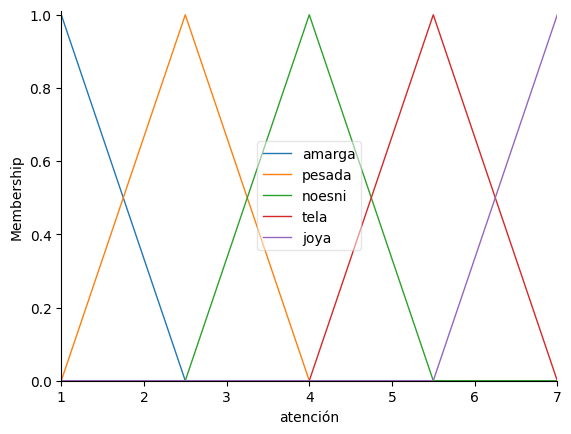

In [4]:
# automf crea membresías triangulares equiespaciadas.
# Aquí se usan cinco etiquetas, una para cada término de atención.
etiquetas_atención = ["amarga", "pesada", "noesni", "tela", "joya"]
atención.automf(names=etiquetas_atención)
atención.view()

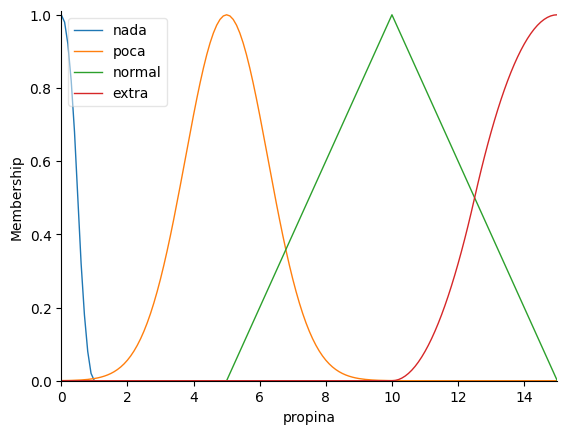

In [5]:
# El consecuente también necesita una membresía por término lingüístico.
etiquetas_propina = ["nada", "poca", "normal", "extra"]
propina.automf(names=etiquetas_propina)
propina["nada"] = fuzz.zmf(propina.universe, 0, 1)
propina["poca"] = fuzz.gaussmf(propina.universe, 5, 1.25)
propina["extra"] = fuzz.smf(propina.universe, 10, 15)
propina.view()

## Base de reglas difusas

Las reglas codifican una política simple: malas experiencias reducen la propina, experiencias buenas la acercan a lo normal y una combinación excepcional habilita una propina extra.

- Si la calidad es `pésima` y la atención es `amarga`, entonces la propina es `nada`.
- Si la calidad es `malita` o `piola`, entonces la propina es `poca`.
- Si la atención es `pesada` o `noesni`, entonces la propina es `poca`.
- Si la calidad es `de pana` o la atención es `tela`, entonces la propina es `normal`.
- Si la calidad es `basadísima` y la atención es `joya`, entonces la propina es `extra`.

En `scikit-fuzzy`, `&` combina antecedentes con mínimo y `|` con máximo. Las reglas activadas recortan sus consecuentes, se agregan con máximo y `propina` se desfusifica por centroide.

In [6]:
# Cada ctrl.Rule implementa una regla de la lista anterior.
# Los operadores & y | usan mínimo y máximo, respectivamente.
reglas = [
    ctrl.Rule(calidad['pésima'] & atención['amarga'], propina['nada']),
    ctrl.Rule(calidad['malita'] | calidad['piola'], propina['poca']),
    ctrl.Rule(atención['pesada'] | atención['noesni'], propina['poca']),
    ctrl.Rule(calidad['de pana'] | atención['tela'], propina['normal']),
    ctrl.Rule(calidad['basadísima'] & atención['joya'], propina['extra']),
]

In [7]:
# El sistema reúne la base de reglas Mamdani.
control_propina = ctrl.ControlSystem(reglas)

In [8]:
# Creamos una simulación independiente del sistema.
dejar_propina = ctrl.ControlSystemSimulation(control_propina)

# Entradas numéricas observadas en el restaurante.
dejar_propina.input['calidad'] = 4.32
dejar_propina.input['atención'] = 5.123

# compute() fusifica, evalúa las reglas, implica, agrega y desfusifica.
dejar_propina.compute()


In [9]:
# La salida es el centroide del conjunto difuso agregado de propina.

print("\nLa propina debe ser de un", str(dejar_propina.output['propina'])+"%\n")



La propina debe ser de un 8.096795815448916%



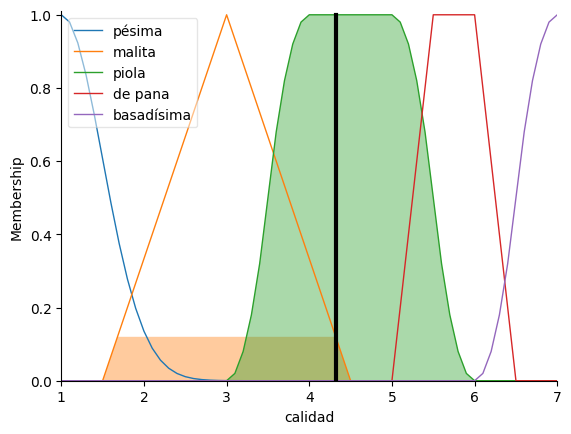

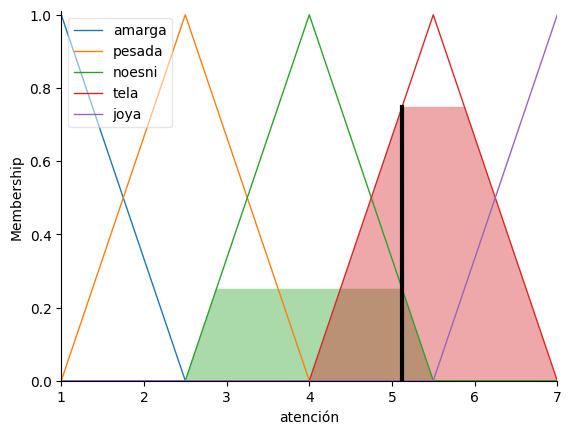

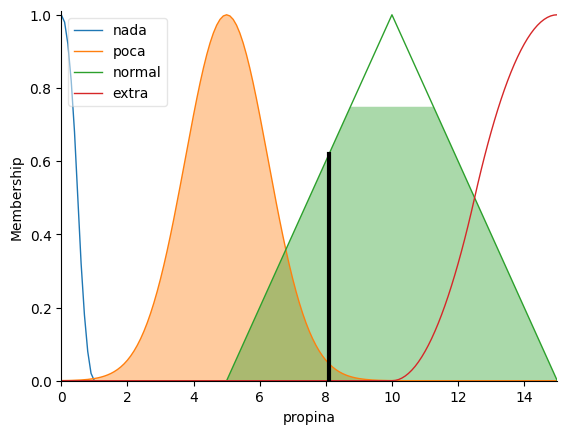

In [10]:
# Las gráficas muestran los grados activados y la salida agregada.
calidad.view(sim=dejar_propina)
atención.view(sim=dejar_propina)
propina.view(sim=dejar_propina)

## Ejercicio complementario: aire acondicionado

Ud. ha sido contratado por IPD-Electrónics para trabajar en su marca TEL-Air que comercializará equipos de aire acondicionado. Estos dispositivos climatizan ambientes interiores en el rango entre $17ºC$ a $30ºC$, lanzando aire frio o aire caliente dependiendo de las instrucciones que el usuario le entregue, hasta llegar a la temperatura deseada. Así:

* Para climatizar utilizando el modo _calor_, el aire acondicionado lanza aire caliente constante, a unos $42ºC$, hasta llegar a la temperatura deseada. 
* Para climatizar utilizando el modo _frío_, el aire acondicionado lanza aire fresco constante, a unos $13ºC$, hasta llegar a la temperatura deseada.
* Para mantener el clima actual del ambiente se utiliza el modo _stand by_, que provee de circulación del aire sin modificar la variación normal de la temperatura.
* Para climatizar automáticamente se utiliza el modo _auto_, el cual se encarga de escoger el modo del aire acondicionado, y el nivel de velocidad utilizado.

El aire es lanzado por los dispositivos en tres posibles velocidades: baja, media o alta. Estas velocidades modifican la temperatura, según el modo de aire y las caractiristicas de la zona climatizada, en los rangos (en $\frac{ºC}{\text{min}}$) $[0.1, 0.7]$, $[0.5, 1.2]$ y $[0.8, 1.9]$, respectivamente. Considere que si está en modo _stand by_ estas variaciones se darán para acercarse a la temperatura del exterior.  

Para controlar la temperatura del ambiente, los dispositivos cuentan con un termostato que les indica la temperatura actual de la zona climatizada.

Considere que para limitar el consumo energético, el modo _auto_ define las siguientes reglas bases:
* Si la diferencia de temperatura es negativa, debe utilizar modo calor.
* Si la diferencia de temperatura es positiva, debe utilizar modo frío.
* Si no hay diferencia de temperatura, debe utilizar el modo stand by.
* Si se encuentra cercano o en la temperatura deseada, no puede utilizar el modo de velocidad alta.
* Si se encuentra muy alejado en la tempratura, debe utilizar el modo de velocidad alta. 

Y que además, utilizando el historico de temperatura actual y de destino, reflejado en las configuraciones manuales, se ha determinado qué:
* La temperatura puede ser catalogada como fría si está bajo el umbral de los 15ºC.
* La temperatura puede ser catalogada como fresca si está en el rango de los 12.5ºC a los 20ºC.
* La temperatura puede ser catalogada como ambiente entre los 18ºC a los 25ºC.
* La temperatura puede ser catalogada como calurosa sobre el rango de los 23ºC.

Y como es un sistema basado en la percepción y el comfort humano, se definen las siguientes reglas básicas:
* Si la temperatura es fría, el aire debe utilizar modo calor. 
* Si la temperatura es calurosa, el aire debe utilizar modo frío.

1. Genere un sistema de inferencia difusa que permita para un instante determinado, utilizando el modo _auto_, determinar el modo de función del dispositivo y la velocidad con la cual lanza el aire. Determine claramente los antecendentes y los consecuentes del sistema, funciones de membresía y las reglas de inferencia difusa del sistema.

In [11]:
# Incluir librerías
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

## Variables
### Antecedentes

In [12]:
amb = ctrl.Antecedent(np.arange(0, 40.5, 0.5), 'ambiente') #frio, fresco, ambiente, caluroso
dif = ctrl.Antecedent(np.arange(-30, 23.5, 0.5), 'diferencia') #muy negativo, negativo, neutro, positivo, muy positivo

### Consecuentes

In [13]:
vel = ctrl.Consequent(np.arange(0.1, 2.0, 0.1), "velocidad") # baja, media, alta
modo = ctrl.Consequent(np.arange(-1,1.01, 0.01), "modo") #frio, stand by, calor

# Membresías

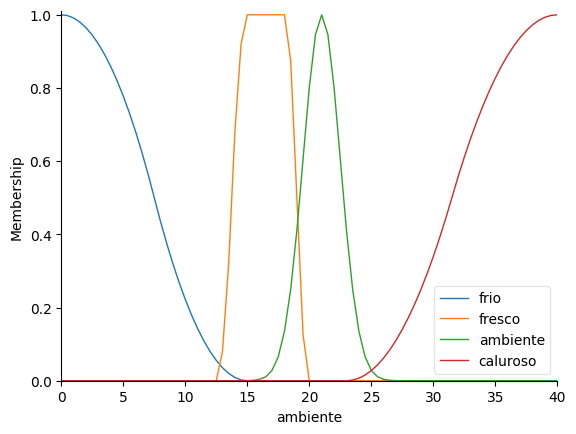

In [14]:
amb['frio'] = fuzz.zmf(amb.universe, 0,15)
amb['fresco'] = fuzz.pimf(amb.universe, 12.5, 15, 18, 20)
amb['ambiente'] = fuzz.gaussmf(amb.universe, 21, 1.5)
amb['caluroso'] = fuzz.smf(amb.universe, 23, 40)
amb.view()

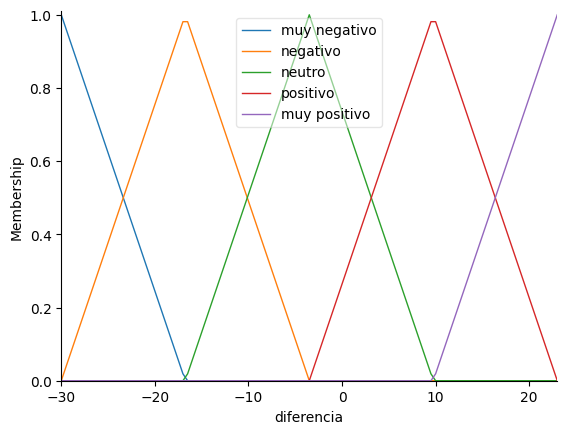

In [15]:
diffs = ['muy negativo', 'negativo', 'neutro', 'positivo', 'muy positivo']
dif.automf(names=diffs)
dif.view()

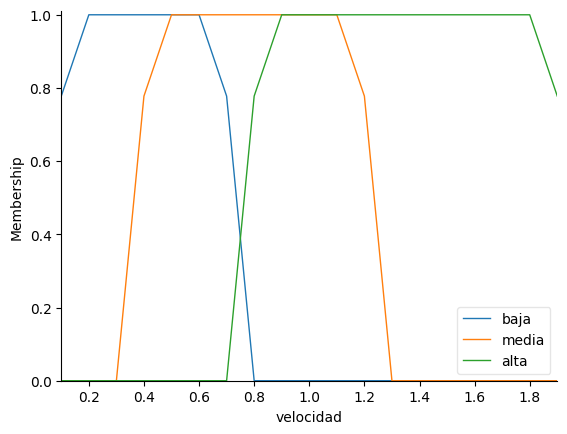

In [16]:
vel['baja'] = fuzz.pimf(vel.universe, 0.0, 0.15, 0.65, 0.8)
vel['media'] = fuzz.pimf(vel.universe, 0.3, 0.45, 1.15, 1.3)
vel['alta'] = fuzz.pimf(vel.universe, 0.7, 0.85, 1.85, 2.0)
vel.view()

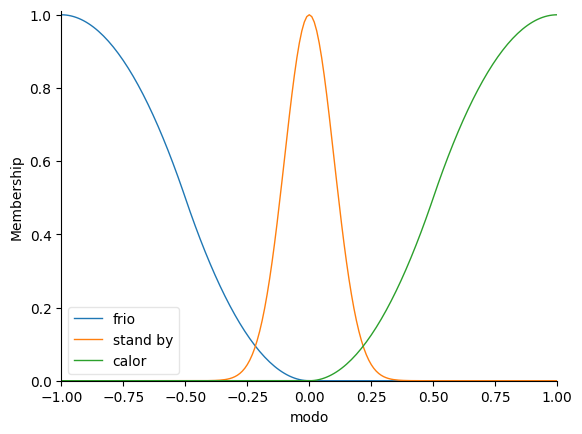

In [17]:
modo['frio'] = fuzz.zmf(modo.universe,-1,0)
modo['stand by'] = fuzz.gaussmf(modo.universe, 0, 0.1) 
modo['calor'] = fuzz.smf(modo.universe, 0, 1)
modo.view()

Considere que para limitar el consumo energético, el modo _auto_ define las siguientes reglas bases:
* Si la diferencia de temperatura es negativa, debe utilizar modo calor.
* Si la diferencia de temperatura es positiva, debe utilizar modo frío.
* Si no hay diferencia de temperatura, debe utilizar el modo stand by.
* Si se encuentra cercano o en la temperatura deseada, no puede utilizar el modo de velocidad alta.
* Si se encuentra muy alejado en la tempratura, debe utilizar el modo de velocidad alta. 

Y como es un sistema basado en la percepción y el comfort humano, se definen las siguientes reglas básicas:
* Si la temperatura es fría, el aire debe utilizar modo calor. 
* Si la temperatura es calurosa, el aire debe utilizar modo frío.

In [18]:
r1 = ctrl.Rule(dif['negativo'] | dif['muy negativo'], modo['calor'])
r2 = ctrl.Rule(dif['positivo'] | dif['muy positivo'], modo['frio'])
r3 = ctrl.Rule(dif['neutro'], modo['stand by'])
r4_1 = ctrl.Rule(dif['neutro'] | dif['negativo'] | dif['positivo'], vel['baja'])
r4_2 = ctrl.Rule(dif['neutro'] | dif['negativo'] | dif['positivo'], vel['media'])
r5 = ctrl.Rule(dif['muy negativo'] | dif['muy positivo'], vel['alta'])

r6 = ctrl.Rule(amb['frio'], modo['calor'])
r7 = ctrl.Rule(amb['caluroso'], modo['frio'])

ctrl_aire = ctrl.ControlSystem([r1, r2, r3, r4_1, r4_2, r5, r6, r7])

In [19]:
AC = ctrl.ControlSystemSimulation(ctrl_aire)

t_ambiente = 20.0
t_destino = 17.0

AC.input['ambiente'] = t_ambiente
AC.input['diferencia'] = t_ambiente - t_destino

AC.compute()

-0.4280042238111107
0.6837784771776448


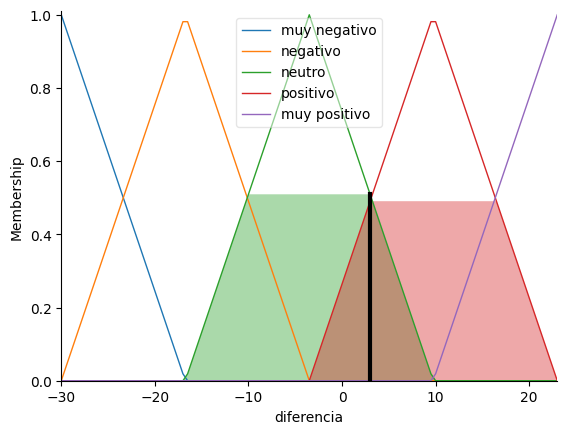

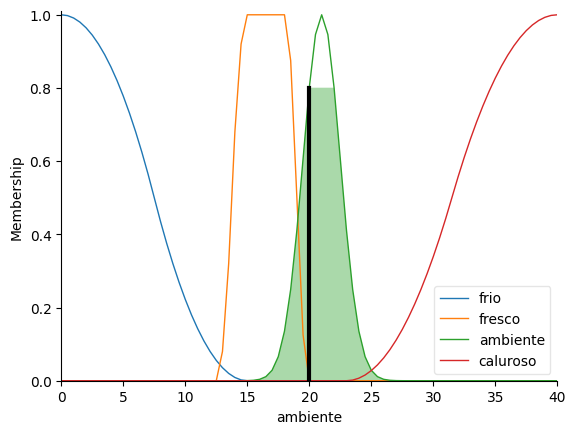

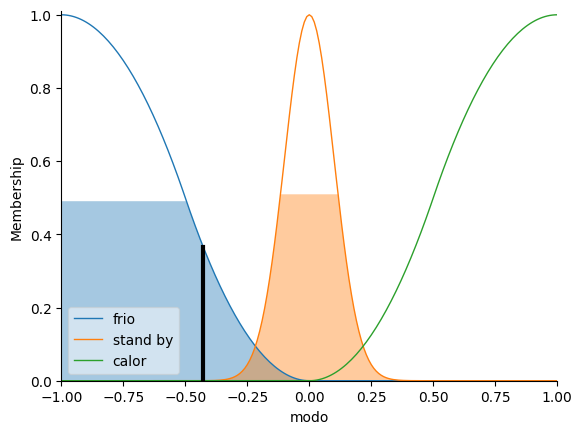

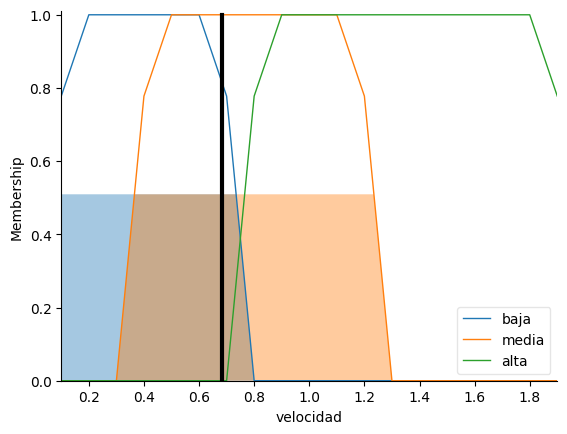

In [20]:
print(AC.output['modo'])
print(AC.output['velocidad'])
dif.view(sim=AC)
amb.view(sim=AC)
modo.view(sim=AC)
vel.view(sim=AC)

2. Simule un sistema de control difuso, que muestre como funcionaría el dispositivo durante 15 minutos, considerando una actualización de las condiciones cada 30 segundos.